In [1]:
!pip install sam3


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install triton-windows


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import torch
print(f"Is CUDA available? {torch.cuda.is_available()}")
print(f"GPU Name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'Still CPU...'}")

Is CUDA available? True
GPU Name: NVIDIA T1000


Loading SAM 3 onto cuda...
Searching for: 'object'...

🎯 ROBOTIC GRASPING COORDINATES EXTRACTED:
Bounding Box: [227.6, 190.1, 335.9, 281.4]
Target Center (X, Y): (281.8, 235.8)



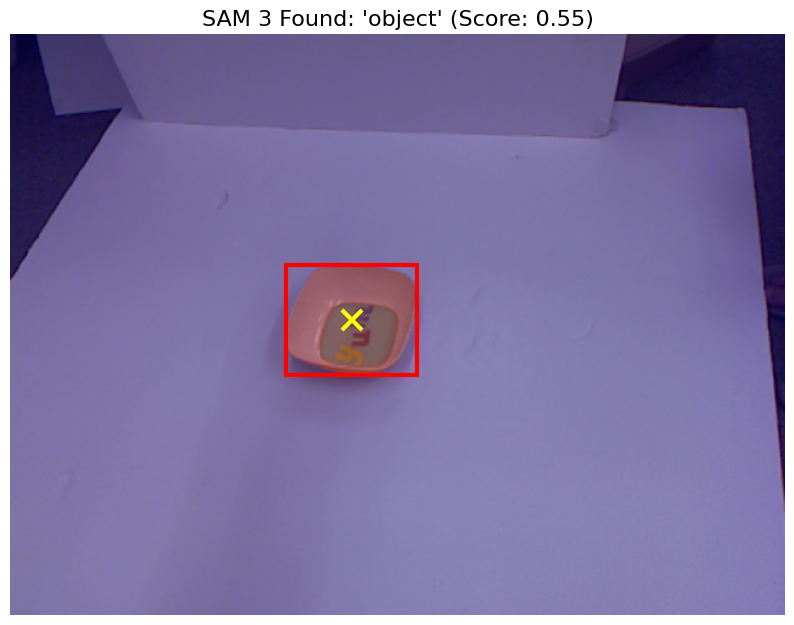

In [ ]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Native SAM 3 imports
from sam3.model_builder import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor

device = "cuda" if torch.cuda.is_available() else "cpu"

# ==========================================
# 1. LOAD THE MODEL 
# ==========================================
print(f"Loading SAM 3 onto {device}...")
model = build_sam3_image_model(
    checkpoint_path="sam3.pt",
    bpe_path="bpe_simple_vocab_16e6.txt.gz"
).to(device)

processor = Sam3Processor(model)

# ==========================================
# 2. LOAD YOUR UPLOADED IMAGE
# ==========================================
img_path = r"C:\Users\park2\Desktop\ME592_HW2\robotic-grasping\6_test_images\pcd0802r.png" 
image_pil = Image.open(img_path).convert("RGB")
inference_state = processor.set_image(image_pil)

# ==========================================
# 3. TEXT INFERENCE (Here is the text_prompt!)
# ==========================================
text_prompt = "object"
print(f"Searching for: '{text_prompt}'...")

output = processor.set_text_prompt(state=inference_state, prompt=text_prompt)

masks = output["masks"]
boxes = output["boxes"]
scores = output["scores"]

# ==========================================
# 4. VISUALIZE AND EXTRACT ROBOT COORDINATES
# ==========================================
plt.figure(figsize=(10, 10))
plt.imshow(image_pil)

if len(masks) > 0:
    # Convert from GPU to CPU, then SQUEEZE out the extra dimension
    mask = masks[0].cpu().numpy() if torch.is_tensor(masks[0]) else masks[0]
    mask = mask.squeeze()  # <--- The fix for the shape error!
    
    box = boxes[0].cpu().numpy() if torch.is_tensor(boxes[0]) else boxes[0]
    
    # Draw Mask
    plt.imshow(mask, alpha=0.4, cmap='jet')
    
    # Draw Bounding Box [x_min, y_min, x_max, y_max]
    x_min, y_min, x_max, y_max = box[0], box[1], box[2], box[3]
    rect = plt.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, 
                         edgecolor='red', facecolor='none', lw=3)
    plt.gca().add_patch(rect)
    
    plt.title(f"SAM 3 Found: '{text_prompt}' (Score: {scores[0]:.2f})", fontsize=16)
    
    # --- HOMEWORK EXTRAS: Grasping Coordinates ---
    center_x = (x_min + x_max) / 2
    center_y = (y_min + y_max) / 2
    
    # Plot the center grasping point
    plt.plot(center_x, center_y, 'x', color='yellow', markersize=15, markeredgewidth=3)
    
    print("\n" + "="*40)
    print("ROBOTIC GRASPING COORDINATES EXTRACTED:")
    print(f"Bounding Box: [{x_min:.1f}, {y_min:.1f}, {x_max:.1f}, {y_max:.1f}]")
    print(f"Target Center (X, Y): ({center_x:.1f}, {center_y:.1f})")
    print("="*40 + "\n")

else:
    plt.title(f"SAM 3 couldn't find '{text_prompt}'")
    print("No object detected.")

plt.axis('off')
plt.show()